# DBI BHMM

While varying the diagonal operator and hence the rotation generator for each double-bracket iteration might be effective in the beginning of a diagonalization, it is unclear if varying it is necessary. In fact,Moore, Mahony and Helmke (MMH) discovered that a fixed $D$ may be sufficiently good for diagonalization when it's  non-degenerate (different eigenvalues) and in ascending order. What we do not know is whether it can be as effective as the variational DBI, and what fixed $D$ would be optimal for diagonalization.

Hence, we aim to understand how well BHMM performs, by following these steps:

1. Show that a fixed $D$ does diagonalize a hamiltonian (e.g. min-max, eigen). This one will work due to the BHMM theory. 

2. Compare some options for $D$, including constant, linear, and quadratic field vector $B$, within the constraint $D=H(B, J=0)=\sum B_iZ_i$, which is the magnetic field hamiltonian.

3. Extend the above to the classical Ising model, where $D=H(B,J)=\sum B_iZ_i + \sum J_{ij}Z_iZ_j$

# BHMM diagonalizes hamiltonian through DBI
In this section, our options include:

1. $D=\text{diag}(\min\Delta(H), \min\Delta(H)+\delta, ..., \max\Delta(H))$, where $\delta = \frac{\max\Delta(H)-\min\Delta(H)}{L}$.This corresponds to taking L equidistant values between the minimum and maximum of diagonal restriction of H. We refer to this as the "min-max" operator.
2. $D=(\lambda_1, ...,\lambda_{2^L})$, where $\lambda_i$ is the $i^{th}$ eigenvalue of $H$ in ascending order.While this choice may seem counterintuitive as having access to the eigenvalues trivializes the double-bracket flow algorithm, it is interesting to see its convergence rate.

## Initialize system
Our primary target hamiltonian is the transverse field Ising model. Here, we employ the `qibo` inbuilt hamiltonian, setting parameters `n` and `h`.

In [1]:
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

from qibo import hamiltonians, set_backend
from qibo.hamiltonians import Hamiltonian, SymbolicHamiltonian
from qibo.quantum_info import random_hermitian
from qibo.models.dbi.double_bracket import DoubleBracketGeneratorType, DoubleBracketScheduling, DoubleBracketIteration
from qibo.models.dbi.utils import *

In [2]:
def visualize_matrix(matrix, title=""):
    """Visualize hamiltonian in a heatmap form."""
    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_title(title)
    try:
        im = ax.imshow(np.absolute(matrix), cmap="inferno")
    except TypeError:
        im = ax.imshow(np.absolute(matrix.get()), cmap="inferno")
    fig.colorbar(im, ax=ax)

In [3]:
def normalize_matrix(matrix):
    # Restrict the maximum abs value of an array to 1
    return matrix/np.max(np.abs(matrix))

[Qibo 0.2.5|INFO|2024-03-15 17:59:09]: Using qibojit (numba) backend on /CPU:0


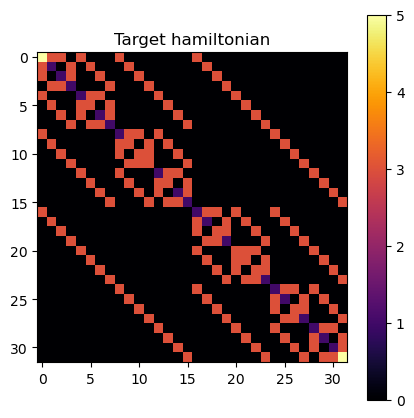

In [37]:
# set the qibo backend (we suggest qibojit if N >= 20)
set_backend("qibojit", "numba")

# hamiltonian parameters
nqubits = 5
h = 3

# define the hamiltonian
H_TFIM = hamiltonians.TFIM(nqubits=nqubits, h=h)

# vosualize the matrix
visualize_matrix(H_TFIM.matrix, title="Target hamiltonian")

## Generate the fixed diagonal operators

In [38]:
# min-max
min_max = diagonal_min_max(H_TFIM.matrix)
# eigen
eigen = np.diag(np.linalg.eigvalsh(H_TFIM.matrix))
# compare the 2
diff = np.diag(min_max) - np.diag(eigen)
normalize_min_max = normalize_matrix(min_max)
normalize_eigen = normalize_matrix(eigen)

/Users/pethidine/anaconda3/envs/DBF_qibo/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/pethidine/anaconda3/envs/DBF_qibo/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 0, 'Entry')

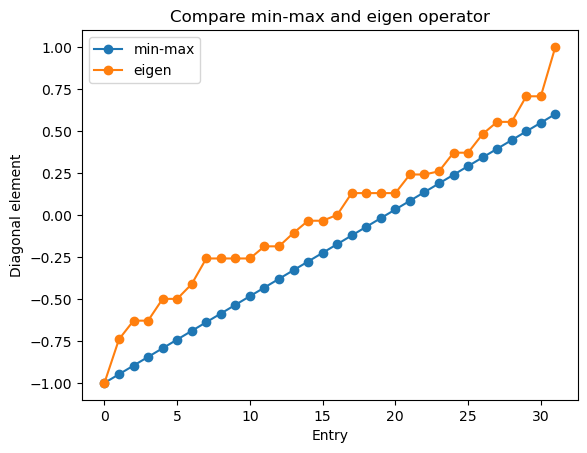

In [39]:
plt.plot(np.diag(normalize_min_max), marker='o', label='min-max')
plt.plot(np.diag(normalize_eigen), marker='o', label='eigen')
plt.legend()
plt.title('Compare min-max and eigen operator')
plt.ylabel('Diagonal element')
plt.xlabel('Entry')

We see that both operators are ascending. While the `min-max` operator is non-degenerate, the `eigen` operator has some degeneracies. It is also noticeable that the `eigen` operator has a wider range of values compared to `min-max`. Next, we compare their performance in diagonalization.

In [53]:
NSTEPS = 15
mode = DoubleBracketGeneratorType.single_commutator
scheduling = DoubleBracketScheduling.grid_search
dbi_min_max = DoubleBracketIteration(deepcopy(H_TFIM), mode=mode, scheduling=scheduling)
dbi_eigen = DoubleBracketIteration(deepcopy(H_TFIM), mode=mode, scheduling=scheduling)
off_diagonal_min_max = [dbi_min_max.off_diagonal_norm]
off_diagonal_eigen = [dbi_eigen.off_diagonal_norm]
step_min_max_history = [0]
step_eigen_history = [0]

In [54]:
for _ in range(NSTEPS):
    step_min_max = dbi_min_max.choose_step(d=min_max, step_max=0.5, max_evals=200)
    step_eigen = dbi_eigen.choose_step(d=eigen, step_max=0.2, step_min=1e-3, max_evals=200)
    print(step_eigen)
    dbi_min_max(step=step_min_max, d=min_max)
    dbi_eigen(step=step_eigen, d=eigen)
    off_diagonal_min_max.append(dbi_min_max.off_diagonal_norm)
    off_diagonal_eigen.append(dbi_eigen.off_diagonal_norm)
    step_min_max_history.append(step_min_max)
    step_eigen_history.append(step_eigen)

0.111
0.004
0.003
0.003
0.003
0.019000000000000003
0.001
0.006
0.002
0.005
0.002
0.002
0.004
0.002
0.002


Text(0.5, 1.0, 'DBI on TFIM n=5, h=3')

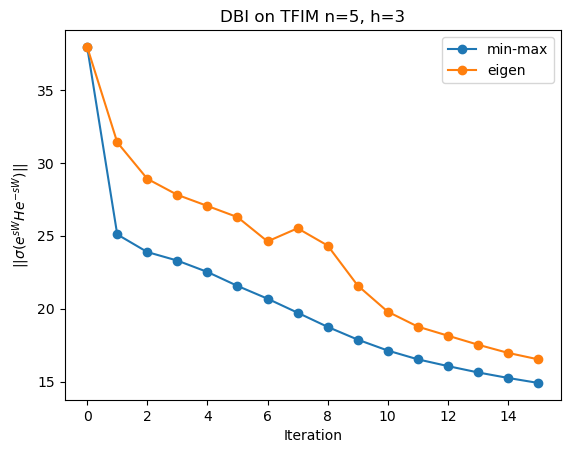

In [51]:
plt.plot(off_diagonal_min_max, marker='o', label='min-max')
plt.plot(off_diagonal_eigen, marker='o', label='eigen')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel(r'$|| \sigma(e^{sW}He^{-sW}) || $')
plt.title(f'DBI on TFIM n={nqubits}, h={h}')

In [55]:
step_turn = step_eigen_history[1]
print(step_turn)
# first step evolution
dbi_init = DoubleBracketIteration(deepcopy(H_TFIM), mode=mode, scheduling=scheduling)
dbi_turn = DoubleBracketIteration(deepcopy(H_TFIM), mode=mode, scheduling=scheduling)
dbi_turn(d=eigen, step=step_turn)
s_space = np.linspace(0,1,500)
loss_initial_scan = []
loss_turn_scan = []
for s in s_space:
    loss_initial_scan.append(dbi_init.loss(d=normalize_eigen,step=s))
    loss_turn_scan.append(dbi_turn.loss(d=normalize_eigen, step=s))

0.111


In [56]:
s_space[np.argmin(loss_turn_scan)]

0.06412825651302605

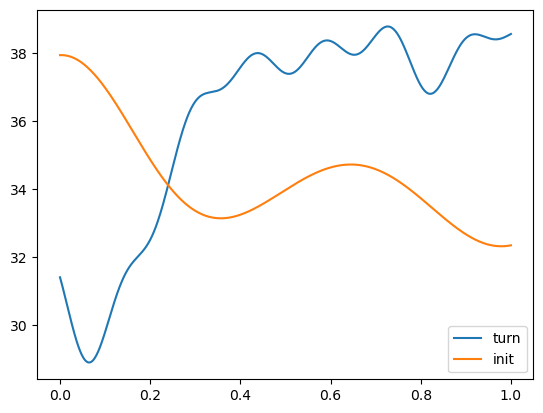

In [57]:
plt.plot(s_space, loss_turn_scan, label='turn')
plt.plot(s_space, loss_initial_scan, label='init')
plt.legend()

We notice that the `min-max` case stops diagonalizing after the very first step. This phenomenon is not changed regardless of the `hyperopt` settings.
We want to know if this is specific to TFIM. Hence, we test both on random Hamiltonians.

### Test on random hamiltonian

In [14]:
seed = 5
H = Hamiltonian(nqubits=nqubits, matrix=random_hermitian(2**nqubits, seed=seed))
# min-max
min_max = diagonal_min_max(H.matrix)
# eigen
eigen = np.diag(np.linalg.eigvalsh(H.matrix))
# compare the 2
diff = np.diag(min_max) - np.diag(eigen)

Text(0.5, 0, 'Entry')

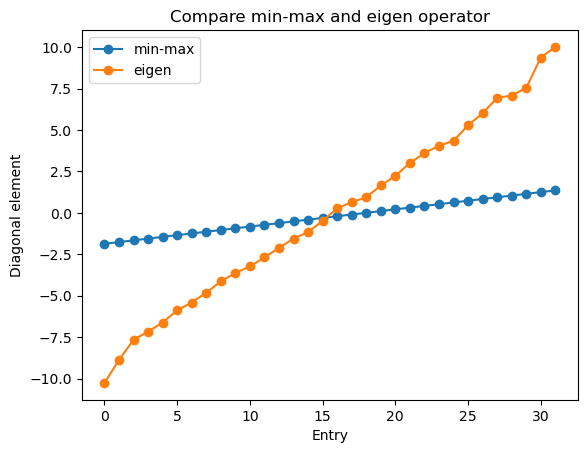

In [15]:
plt.plot(np.diag(min_max), marker='o', label='min-max')
plt.plot(np.diag(eigen), marker='o', label='eigen')
plt.legend()
plt.title('Compare min-max and eigen operator')
plt.ylabel('Diagonal element')
plt.xlabel('Entry')

In [172]:
NSTEPS = 15
mode = DoubleBracketGeneratorType.single_commutator
scheduling = DoubleBracketScheduling.hyperopt
dbi_min_max = DoubleBracketIteration(deepcopy(H), mode=mode, scheduling=scheduling)
dbi_eigen = DoubleBracketIteration(deepcopy(H), mode=mode, scheduling=scheduling)
off_diagonal_min_max = [dbi_min_max.off_diagonal_norm]
off_diagonal_eigen = [dbi_eigen.off_diagonal_norm]
step_min_max_history = [0]
step_eigen_history = [0]

NameError: name 'H' is not defined

In [100]:
for _ in range(NSTEPS):
    step_min_max = dbi_min_max.choose_step(d=min_max, step_min=1e-4,step_max=2, optimizer=hyperopt.atpe)
    step_eigen = dbi_eigen.choose_step(d=eigen, step_min=1e-4,step_max=2, optimizer=hyperopt.atpe)
    dbi_min_max(step=step_min_max, d=min_max)
    dbi_eigen(step=step_eigen, d=eigen)
    off_diagonal_min_max.append(dbi_min_max.off_diagonal_norm)
    off_diagonal_eigen.append(dbi_eigen.off_diagonal_norm)
    step_min_max_history.append(step_min_max)
    step_eigen_history.append(step_eigen)

Text(0.5, 1.0, 'Random Hamitlonian, seed=5')

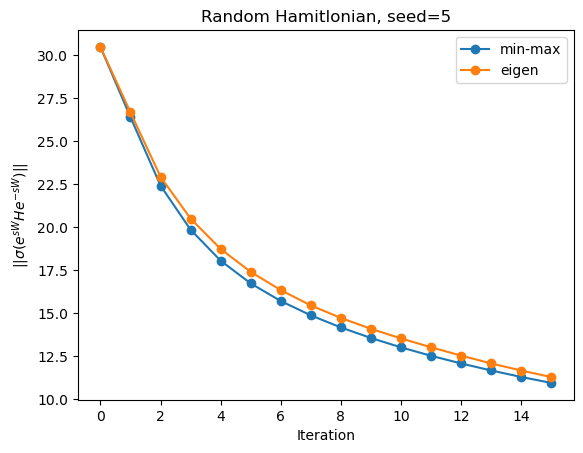

In [ ]:
plt.plot(off_diagonal_min_max, marker='o', label='min-max')
plt.plot(off_diagonal_eigen, marker='o', label='eigen')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel(r'$|| \sigma(e^{sW}He^{-sW}) || $')
plt.title(f'Random Hamitlonian, seed={seed}')

The answer is Yes. That is, the `min-max` operator is only able to diagonalize `H_TFIM` for 1-step, but not necessarily for other hamiltonians.

In [ ]:
print(step_eigen_history)
print(step_min_max_history)

[0, 0.012171760855043741, 0.007595753228579506, 0.006605656528097322, 0.006901381285361828, 0.00526544728372239, 0.00702224539280984, 0.004835114134691244, 0.006270717247502889, 0.00521250886807318, 0.0059071599164958345, 0.004684173672396728, 0.006975072369091696, 0.004381977692825738, 0.006828922355530943, 0.0043207069327722255]
[0, 0.07360395931520121, 0.046034914342171884, 0.04300050089396292, 0.03815721701666929, 0.038877127156860335, 0.03523322118427389, 0.03714152552797491, 0.033742768198180964, 0.0365480557154796, 0.03202186047078974, 0.0372876187645212, 0.030815774545239965, 0.038968260955376144, 0.029483377390390104, 0.038799359991072965]


Text(0, 0.5, 'Step duration')

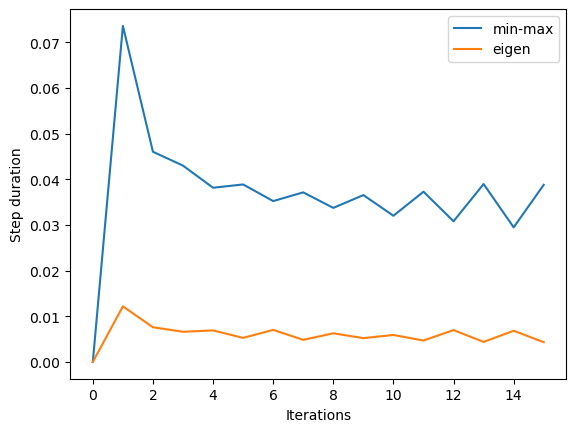

In [ ]:
plt.plot(step_min_max_history, label='min-max')
plt.plot(step_eigen_history, label='eigen')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Step duration')

## Compare BHMM magnetic field operator
$D=\sum B_iZ_i$

In [129]:
# generate Z operators
Z_ops = generate_onsite_Z_ops(nqubits)

[Qibo 0.2.5|WARNING|2024-03-11 16:01:27]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-11 16:01:27]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-11 16:01:27]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-11 16:01:27]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-11 16:01:27]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.


In [132]:
def B_order(nqubits, order, Z_ops):
    coef = np.array([(i+1)**order for i in range(nqubits)])
    return np.sum(coef.reshape(-1,1,1)*Z_ops, 0)

highest_order_test = 2
B_ops = [B_order(nqubits, order, Z_ops) for order in range(highest_order_test+1)]
B_normalize_ops = list(map(normalize_matrix, B_ops))

/Users/pethidine/anaconda3/envs/DBF_qibo/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/pethidine/anaconda3/envs/DBF_qibo/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Sorted diagonal entries')

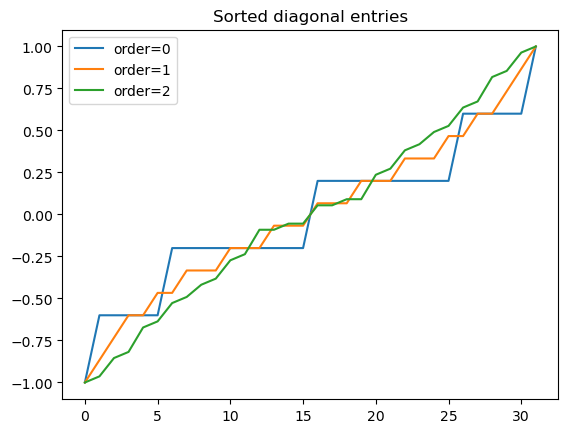

In [134]:
# visualizing the matrices: degeneracy
sort_B_ops = [np.sort(np.diag(B_op)) for B_op in B_normalize_ops]
for order, sort_B_op in enumerate(sort_B_ops):
    plt.plot(sort_B_op, label=f'order={order}')
plt.legend()
plt.title('Sorted diagonal entries')

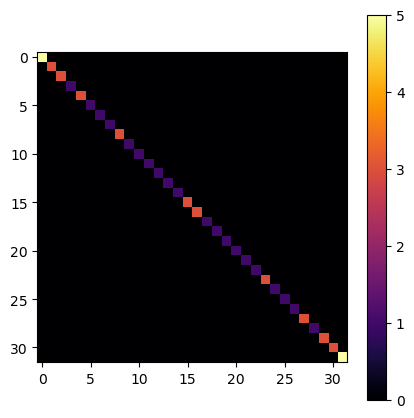

In [ ]:
# visualize matrix
visualize_matrix(B_ops[0])

We see that with high order, the operator is less degenderate. We also see that the operators are not of ascending order. Hence, we would like to check whether having degeneracy and mixed order prohibits diagonalization.

In [ ]:
# initialize for tests
NSTEPS = 15
seed = 10
# H = Hamiltonian(nqubits=nqubits, matrix=random_hermitian(2**nqubits, seed=seed))

nqubits = 5
h = 2
H = hamiltonians.TFIM(nqubits=nqubits, h=h)

mode = DoubleBracketGeneratorType.single_commutator
scheduling = DoubleBracketScheduling.hyperopt
off_diag_norm_orders = []
step_orders = []
for order in range(highest_order_test+1):
    dbi = DoubleBracketIteration(deepcopy(H),mode=mode, scheduling=scheduling)
    off_diag_norm = [dbi.off_diagonal_norm]
    steps = [0]
    for _ in range(NSTEPS):
        step = dbi.choose_step(d=B_ops[order], max_evals=300)
        dbi(step=step, d=B_ops[order])
        off_diag_norm.append(dbi.off_diagonal_norm)
        steps.append(step)
    off_diag_norm_orders.append(off_diag_norm)
    step_orders.append(steps) 
        

Text(0.5, 1.0, 'TFIM, n=5 h=2')

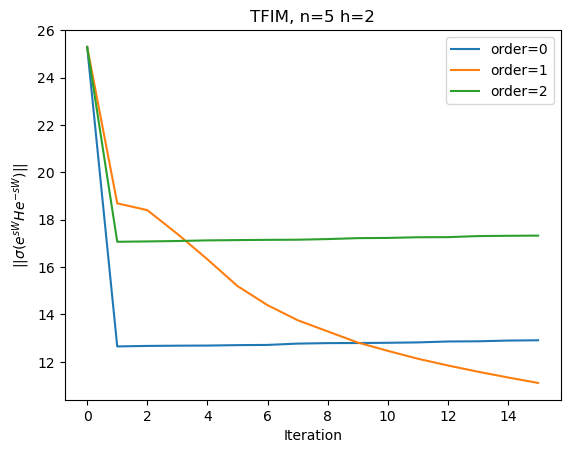

In [ ]:
for order in range(highest_order_test+1):
    plt.plot(off_diag_norm_orders[order], label=f'order={order}')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel(r'$|| \sigma(e^{sW}He^{-sW}) || $')
# plt.title(f'Random Hamitlonian, seed={seed}')
plt.title(f'TFIM, n={nqubits} h={h}')

The above results show that the order of the magnetic expansion has no clear relation to the diagonalization. We then consider 2 factors:
1. Degeneracy
2. Ascending order

Now we sort the diagonal entried of the operators by ascending order and see if there is improvements.

In [ ]:
sorted_B_ops = [np.diag(np.sort(np.diag(matrix))) for matrix in B_ops]

In [ ]:
mode = DoubleBracketGeneratorType.single_commutator
scheduling = DoubleBracketScheduling.grid_search
off_diag_norm_orders = []
step_orders = []
for order in range(highest_order_test+1):
    dbi = DoubleBracketIteration(deepcopy(H),mode=mode, scheduling=scheduling)
    off_diag_norm = [dbi.off_diagonal_norm]
    steps = [0]
    for _ in range(NSTEPS):
        step = dbi.choose_step(d=sorted_B_ops[order])
        dbi(step=step, d=sorted_B_ops[order])
        off_diag_norm.append(dbi.off_diagonal_norm)
        steps.append(step)
    off_diag_norm_orders.append(off_diag_norm)
    step_orders.append(steps) 

Text(0.5, 1.0, 'TFIM, n=5 h=2 with sorted D')

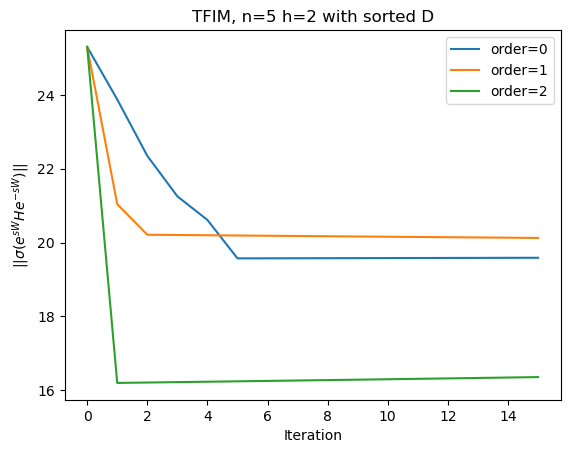

In [ ]:
for order in range(highest_order_test+1):
    plt.plot(off_diag_norm_orders[order], label=f'order={order}')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel(r'$|| \sigma(e^{sW}He^{-sW}) || $')
# plt.title(f'Random Hamitlonian, seed={seed}')
plt.title(f'TFIM, n={nqubits} h={h} with sorted D')

We make the following observations:
1. The degree of diagonalization achieved by these fixed operators is highly dependent on the scheduling method used.
2. There exist scheduling methods such that all of the operators lead to diagonalization of the Hamiltonian.
3. Despite having more degeneracy, the unsorted $B_i=1$ generally gives the most diagonalization.
4. After the sort, the higher order $B$ fields (also less degeneracy) leads to faster initial diagonalization.

## Ising model

Nearest neighbor model: $j=i+1$

$D=\sum B_iZ_i + \sum J_{ij}Z_iZ_j$

In [115]:
# function to generate operator strings
def generate_str_with_n_ops_nn(nqubits, num_Z, pauli_name):
    op_str = []
    for num in range(num_Z):
        pauli_neighbor = pauli_name * (num+1)
        op_str += [''.join(pauli_neighbor if i in positions else 'I' for i in range(nqubits-num)) 
            for positions in combinations(range(nqubits-num), 1)]
    return op_str
# test
op_names = generate_str_with_n_ops_nn(nqubits,2,"Z")
print(op_names)
len(op_names)== 2*nqubits-1

['ZIIII', 'IZIII', 'IIZII', 'IIIZI', 'IIIIZ', 'ZZIII', 'IZZII', 'IIZZI', 'IIIZZ']


True

In [116]:
# generate operators
ising_ops = [SymbolicHamiltonian(str_to_symbolic(op_name)).dense.matrix for op_name in op_names]
# dictionary
op_dict = dict(zip(op_names, ising_ops))


[Qibo 0.2.5|WARNING|2024-03-11 15:12:10]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-11 15:12:10]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-11 15:12:10]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-11 15:12:10]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-11 15:12:10]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-11 15:12:10]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-11 15:12:10]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-11 15:12:10]: Calculating the dens

In [122]:
B = 1
J = 0.5
constant_coef = np.array([B]*nqubits + [J]*(nqubits-1))

In [ ]:
# generate coefficients for the Ising model
def ising_coef_of_order(nqubits, num_Z, order):
    ising_coef = []
    for num in range(num_Z):
        for i in combinations(range(1,nqubits+1), num+1):
            ising_coef.append(math.prod(element**order for element in i))
    return np.array(ising_coef)

In [125]:
# linear_coef = ising_coef_of_order(nqubits, 2, 1)
constant_op = np.sum(constant_coef.reshape(-1,1,1)*ising_ops,0)

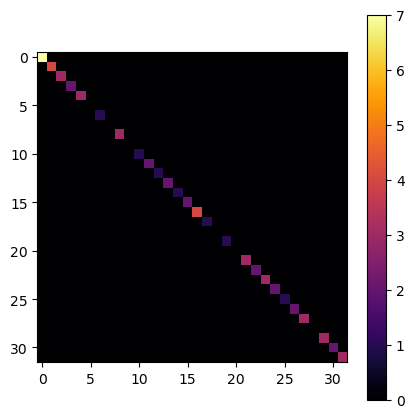

In [126]:
visualize_matrix(linear_op)

/Users/pethidine/anaconda3/envs/DBF_qibo/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/pethidine/anaconda3/envs/DBF_qibo/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Sorted diagonal entries')

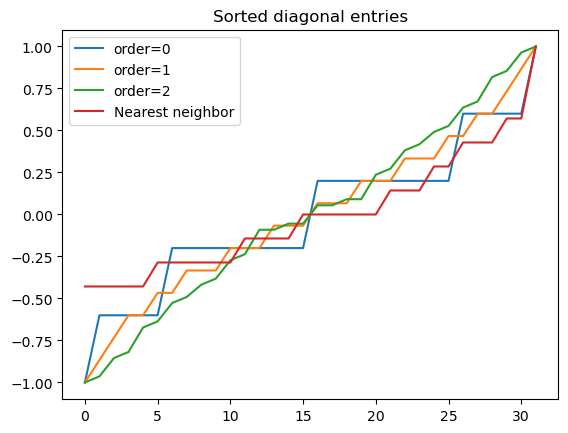

In [140]:
# visualize degeneracy
# visualizing the matrices: degeneracy
sort_B_ops = [np.sort(np.diag(B_op)) for B_op in B_normalize_ops]
for order, sort_B_op in enumerate(sort_B_ops):
    plt.plot(sort_B_op, label=f'order={order}')
plt.plot(np.sort(np.diag(normalize_matrix(linear_op))), label='Nearest neighbor')
plt.legend()
plt.title('Sorted diagonal entries')

## Attempts of other searching algorithms
1. Adapative grid search. Given the loss function and search space, the algorithm runs through the search space like grid search, arriving at a minimum value. Then, another grid search with half the grid size is conducted, finding another minimum. If the 2 minima coincide, we accept it as the global minimum. Otherwise, run grid size by half again, until we find coinciding minimum. This search method does not guarantee finding the first minimum value. A modification can be made, e.g. set tolerance value, in a comparison, accept the one nearer to origin if difference is within tolerence.
2. Golden section search -> very likely to miss a minimum outside the section -> abandon.


In [171]:
import numpy as np

def adaptive_grid_search(loss_function, s_range, initial_evaluations, tolerance=1e-5, reduction_factor=0.5):
    """
    Performs an adaptive grid search using NumPy to find the minimum of the loss_function within s_range,
    starting with a specified number of evaluations.
    
    :param loss_function: A callable loss function to minimize.
    :param s_range: A tuple (start, end) defining the search space.
    :param initial_evaluations: The initial number of points to evaluate within the search space.
    :param tolerance: The convergence criterion for stopping, based on the search space range.
    :param reduction_factor: Factor by which the number of evaluations is reduced after each iteration.
    :return: The point in s_range that approximately minimizes the loss function.
    """
    a, b = s_range
    evaluations = initial_evaluations
    min_point, min_value = None, np.inf

    while (b - a) / evaluations > tolerance:
        # Generate points and evaluate the loss function at these points
        points = np.linspace(a, b, evaluations)
        values = np.vectorize(loss_function)(points)
        
        # Find the minimum value and its corresponding point
        current_min_idx = np.argmin(values)
        current_min_value = values[current_min_idx]
        current_min_point = points[current_min_idx]
        
        # Check if there's improvement
        if min_value > current_min_value:
            min_value = current_min_value
            min_point = current_min_point
            # Focus and refine the search space around the new minimum
            a, b = max(s_range[0], min_point - (b - a) / 4), min(s_range[1], min_point + (b - a) / 4)
        else:
            # Reduce the search space to refine the search if no better minimum is found
            a, b = a + (b - a) * reduction_factor / 2, b - (b - a) * reduction_factor / 2

        # Reduce the number of evaluations to increase the search resolution
        evaluations = max(2, int(evaluations * reduction_factor))
    
    return min_point

# Example usage
if __name__ == "__main__":
    # Define a sample loss function
    def sample_loss_function(x):
        return np.sin(x) + np.sin(10/3 * x) + np.log(x+1) - 0.84*x

    # Define the search space
    search_space = (2.7, 7.5)

    # Find the minimum
    minimum = adaptive_grid_search(sample_loss_function, search_space, initial_evaluations=10)
    print(f"Approximate minimum: x = {minimum}, loss = {sample_loss_function(minimum)}")


Approximate minimum: x = 5.202366129557292, loss = -4.425450264373761


In [191]:
np.random.uniform(-10, 10)

-4.994728130772175

In [255]:
def step_annealing(dbi_object, d, initial_s=None, step_min=1e-4, step_max=1, s_jump_range=None, initial_temp=20, cooling_rate=0.8, min_temp=1e-5, max_iter=200, verbose=False):
    if initial_s is None:
        initial_s,_ = dbi_object.polynomial_step(d=d, n=2)
    if s_jump_range is None:
        s_jump_range = (step_max - step_min)/5
    current_s = initial_s
    current_loss = dbi_object.loss(d=d, step=current_s)
    if verbose:
        print("initial_s", current_s)
        print("initial loss", current_loss)
    temp = initial_temp
    
    for _ in range(max_iter):
        candidate_s = max(step_min, min(current_s + np.random.uniform(-s_jump_range, s_jump_range, step_max)))
        candidate_loss = dbi_object.loss(d=d, step=candidate_s)
        
        # Calculate change in loss
        delta_loss = candidate_loss - current_loss
        
        # Determine if the candidate solution is an improvement
        if delta_loss < 0 or np.random.rand() < math.exp(-delta_loss / temp):
            current_s = candidate_s
            current_loss = candidate_loss
            if verbose:
                print(f"Iter {_} s {candidate_s} accepted with loss {candidate_loss} and prob {math.exp(-delta_loss / temp)} at temp {temp}")
        elif verbose:
            print(f"Iter {_} s {candidate_s} not accepted with prob {math.exp(-delta_loss / temp)}")
        # Cool down
        temp *= cooling_rate
        if temp < min_temp:
            break
    
    return current_s

In [283]:
# initialize for tests
NSTEPS = 15
seed = 10
# H = Hamiltonian(nqubits=nqubits, matrix=random_hermitian(2**nqubits, seed=seed))

nqubits = 5
h = 2
H = hamiltonians.TFIM(nqubits=nqubits, h=h)

# min-max
min_max = diagonal_min_max(H_TFIM.matrix)
# eigen
eigen = np.diag(np.linalg.eigvalsh(H_TFIM.matrix))
# compare the 2
diff = np.diag(min_max) - np.diag(eigen)
normalize_min_max = normalize_matrix(min_max)
normalize_eigen = normalize_matrix(eigen)


mode = DoubleBracketGeneratorType.single_commutator
dbi = DoubleBracketIteration(deepcopy(H),mode=mode, scheduling=scheduling)

In [284]:
step_an = step_annealing(dbi, d=eigen, max_iter=30, initial_temp=1)
print(f"Final step {step_an} loss {dbi.loss(d=eigen, step=step_an)}")

Final step 0.09378184484490273 loss 23.119931708609048


In [299]:
# Run for several iterations
NSTEPS = 10
dbi_eigen = DoubleBracketIteration(deepcopy(H),mode=mode, scheduling=scheduling)
dbi_mm = DoubleBracketIteration(deepcopy(H),mode=mode, scheduling=scheduling)
steps_eigen = [0]
loss_eigen = [dbi_eigen.off_diagonal_norm]
steps_mm = [0]
loss_mm = [dbi_mm.off_diagonal_norm]
for _ in range(NSTEPS):
    step_an_eigen = step_annealing(dbi_eigen, d=eigen, step_min=1e-6, max_iter=100, initial_temp=1)
    step_an_mm = step_annealing(dbi_mm, d=min_max, step_min=1e-6, max_iter=100, initial_temp=1)
    # print(f"{_} step {step_an_eigen} loss {dbi_eigen.loss(d=eigen, step=step_an)}")
    dbi_eigen(d=eigen, step=step_an_eigen)
    dbi_mm(d=min_max, step=step_an_mm)
    steps_eigen.append(step_an_eigen)
    loss_eigen.append(dbi_eigen.off_diagonal_norm)
    steps_mm.append(step_an_mm)
    loss_mm.append(dbi_mm.off_diagonal_norm)

In [300]:
steps_plot_eigen = [sum(steps_eigen[:i+1]) for i in range(NSTEPS+1)]
steps_plot_mm = [sum(steps_mm[:i+1]) for i in range(NSTEPS+1)]

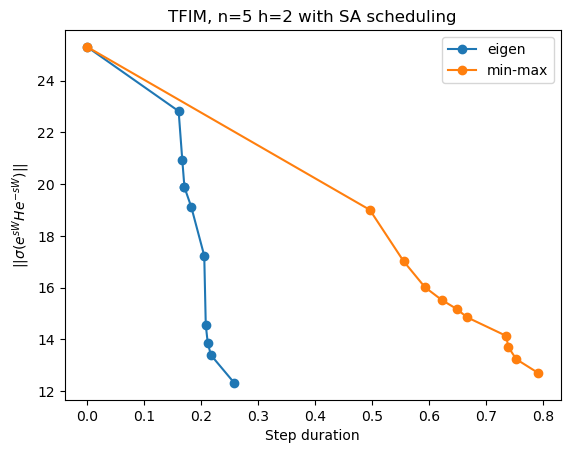

In [304]:
plt.plot(steps_plot_eigen, loss_eigen, marker='o', label='eigen')
plt.plot(steps_plot_mm, loss_mm, marker='o', label='min-max')
plt.xlabel('Step duration')
plt.ylabel(r'$|| \sigma(e^{sW}He^{-sW}) || $')
# plt.title(f'Random Hamitlonian, seed={seed}')
plt.title(f'TFIM, n={nqubits} h={h} with SA scheduling')
plt.legend()

In [ ]:
# Mganetic field